# 08 Leave-One-Subject-Out Evaluation

In this notebook, we evaluate stress classification using Leave-One-Subject-Out cross-validation.

In each fold, one subject is kept as the test subject and all remaining subjects are used for training. This gives a stronger estimate of how well the model generalizes to unseen people.

In [1]:
# Basic libraries for paths, arrays, tables, and plots
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn tools for LOSO evaluation and modeling
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Classical machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [2]:
# Define main project folders
PROJECT_ROOT = Path("..")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

# Create results folder if it does not exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Define feature file path
features_path = PROCESSED_DATA_DIR / "features.csv"

print("Feature file:", features_path)
print("Feature file exists:", features_path.exists())

Feature file: ..\data\processed\features.csv
Feature file exists: True


In [3]:
# Load extracted feature dataset from Notebook 03
features_df = pd.read_csv(features_path)

# Display dataset shape and first rows
print("Feature dataset shape:", features_df.shape)

features_df.head()

Feature dataset shape: (2151, 75)


,subject_id,window_id,start_sec,end_sec,majority_ratio,ECG_mean,ECG_std,ECG_min,ECG_max,ECG_median,...,Temp_rms,Temp_energy,Temp_mean_abs_change,Temp_std_change,Temp_max_abs_change,Temp_zero_crossings,Temp_skewness,Temp_kurtosis,label,label_name
0,S10,0,90.0,120.0,0.904762,0.001516,0.132416,-0.663895,0.785843,0.030716,...,33.897731,1149.056162,0.022942,0.032233,0.183929,0,-0.302280,3.753279,1,Neutral / Baseline
1,S10,1,105.0,135.0,1.000000,0.000542,0.136359,-0.574814,0.821457,0.031586,...,33.922503,1150.736193,0.024211,0.033127,0.177979,0,-0.395398,4.197550,1,Neutral / Baseline
2,S10,2,120.0,150.0,1.000000,0.001889,0.140376,-0.667923,0.821457,0.028976,...,33.949085,1152.540389,0.024425,0.033431,0.177979,0,-0.298644,3.715316,1,Neutral / Baseline
3,S10,3,135.0,165.0,1.000000,0.001967,0.154921,-0.667923,0.838211,0.019730,...,33.982891,1154.836868,0.024582,0.033548,0.179626,0,-0.029038,3.213001,1,Neutral / Baseline
4,S10,4,150.0,180.0,1.000000,0.000855,0.161409,-0.664948,0.838211,0.005791,...,34.028476,1157.937208,0.026112,0.035063,0.179871,0,-0.213312,2.793012,1,Neutral / Baseline


In [4]:
# Label names used in this project
LABEL_NAMES = {
    1: "Neutral / Baseline",
    2: "Stress",
    3: "Amusement"
}

CLASS_LABELS = [1, 2, 3]
CLASS_NAMES = [LABEL_NAMES[label] for label in CLASS_LABELS]

# These columns are metadata or target columns, not input features
metadata_columns = [
    "subject_id",
    "window_id",
    "start_sec",
    "end_sec",
    "majority_ratio",
    "label",
    "label_name"
]

# Select only feature columns
feature_columns = [
    column for column in features_df.columns
    if column not in metadata_columns
]

print("Number of feature columns:", len(feature_columns))
print("Class names:", CLASS_NAMES)

Number of feature columns: 68
Class names: ['Neutral / Baseline', 'Stress', 'Amusement']


In [5]:
# X contains physiological feature values
X = features_df[feature_columns].copy()

# y contains target labels: 1, 2, 3
y = features_df["label"].copy()

# groups contains subject IDs for LOSO splitting
groups = features_df["subject_id"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of subjects:", groups.nunique())
print("Subjects:", sorted(groups.unique()))

X shape: (2151, 68)
y shape: (2151,)
Number of subjects: 15
Subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [6]:
# Check if any feature column has missing values
missing_values = X.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Columns with missing values:", len(missing_values))

# Fill missing values using column mean if needed
if len(missing_values) > 0:
    X = X.fillna(X.mean())
    print("Missing values filled with column means.")
else:
    print("No missing values found.")

Columns with missing values: 0
No missing values found.


In [7]:
# Check overall class distribution
class_distribution = features_df["label_name"].value_counts().reset_index()
class_distribution.columns = ["label_name", "window_count"]

class_distribution

,label_name,window_count
0,Neutral / Baseline,1154
1,Stress,644
2,Amusement,353


In [8]:
# Function creates fresh models for each LOSO run
def create_models():
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            ))
        ]),
        
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42
            ))
        ]),
        
        "Support Vector Machine": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", SVC(
                kernel="rbf",
                class_weight="balanced",
                random_state=42
            ))
        ]),
        
        "Gradient Boosting": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", GradientBoostingClassifier(
                random_state=42
            ))
        ])
    }
    
    return models

# Show model names
models = create_models()

print("Models for LOSO evaluation:")
for model_name in models.keys():
    print("-", model_name)

Models for LOSO evaluation:
- Logistic Regression
- Random Forest
- Support Vector Machine
- Gradient Boosting


In [9]:
# LeaveOneGroupOut leaves one subject out in each fold
logo = LeaveOneGroupOut()

# Store fold-level results and predictions
all_results = []
all_predictions = []

models = create_models()

for model_name, model in models.items():
    print("=" * 70)
    print("Evaluating model:", model_name)
    
    fold_number = 1
    
    for train_index, test_index in logo.split(X, y, groups=groups):
        # Split data for this fold
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]
        
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]
        
        test_subject = groups.iloc[test_index].unique()[0]
        
        # Train model on all subjects except the test subject
        model.fit(X_train, y_train)
        
        # Predict left-out subject
        y_pred = model.predict(X_test)
        
        # Calculate metrics for this subject
        accuracy = accuracy_score(y_test, y_pred)
        macro_precision = precision_score(
            y_test,
            y_pred,
            labels=CLASS_LABELS,
            average="macro",
            zero_division=0
        )
        macro_recall = recall_score(
            y_test,
            y_pred,
            labels=CLASS_LABELS,
            average="macro",
            zero_division=0
        )
        macro_f1 = f1_score(
            y_test,
            y_pred,
            labels=CLASS_LABELS,
            average="macro",
            zero_division=0
        )
        
        # Save fold result
        all_results.append({
            "model": model_name,
            "fold": fold_number,
            "test_subject": test_subject,
            "test_samples": len(y_test),
            "accuracy": accuracy,
            "macro_precision": macro_precision,
            "macro_recall": macro_recall,
            "macro_f1": macro_f1
        })
        
        # Save individual predictions for global confusion matrix later
        fold_predictions = pd.DataFrame({
            "model": model_name,
            "test_subject": test_subject,
            "true_label": y_test.values,
            "predicted_label": y_pred
        })
        
        all_predictions.append(fold_predictions)
        
        print(
            f"Fold {fold_number:02d} | "
            f"Test subject: {test_subject} | "
            f"Accuracy: {accuracy:.4f} | "
            f"Macro F1: {macro_f1:.4f}"
        )
        
        fold_number += 1

Evaluating model: Logistic Regression
Fold 01 | Test subject: S10 | Accuracy: 0.3289 | Macro F1: 0.3024
Fold 02 | Test subject: S11 | Accuracy: 0.4792 | Macro F1: 0.4769
Fold 03 | Test subject: S13 | Accuracy: 0.8207 | Macro F1: 0.6263
Fold 04 | Test subject: S14 | Accuracy: 0.8276 | Macro F1: 0.6102
Fold 05 | Test subject: S15 | Accuracy: 0.3931 | Macro F1: 0.4141
Fold 06 | Test subject: S16 | Accuracy: 0.4825 | Macro F1: 0.4861
Fold 07 | Test subject: S17 | Accuracy: 0.7315 | Macro F1: 0.7170
Fold 08 | Test subject: S2 | Accuracy: 0.6642 | Macro F1: 0.5298
Fold 09 | Test subject: S3 | Accuracy: 0.7391 | Macro F1: 0.5733
Fold 10 | Test subject: S4 | Accuracy: 0.5532 | Macro F1: 0.3020
Fold 11 | Test subject: S5 | Accuracy: 0.7222 | Macro F1: 0.6603
Fold 12 | Test subject: S6 | Accuracy: 0.7902 | Macro F1: 0.6473
Fold 13 | Test subject: S7 | Accuracy: 0.1678 | Macro F1: 0.0958
Fold 14 | Test subject: S8 | Accuracy: 0.4577 | Macro F1: 0.4608
Fold 15 | Test subject: S9 | Accuracy: 0.6853

In [10]:
# Convert all fold results into a DataFrame
loso_results_df = pd.DataFrame(all_results)

print("LOSO results shape:", loso_results_df.shape)

loso_results_df.head()

LOSO results shape: (60, 8)


,model,fold,test_subject,test_samples,accuracy,macro_precision,macro_recall,macro_f1
0,Logistic Regression,1,S10,149,0.328859,0.566588,0.507820,0.302448
1,Logistic Regression,2,S11,144,0.479167,0.744898,0.675325,0.476933
2,Logistic Regression,3,S13,145,0.820690,0.725141,0.664322,0.626282
3,Logistic Regression,4,S14,145,0.827586,0.570853,0.659091,0.610185
4,Logistic Regression,5,S15,145,0.393103,0.609824,0.537136,0.414133


In [11]:
# Save fold-level LOSO results
loso_results_path = RESULTS_DIR / "loso_fold_results.csv"

loso_results_df.to_csv(loso_results_path, index=False)

print("Saved LOSO fold results to:", loso_results_path)

Saved LOSO fold results to: ..\results\loso_fold_results.csv


In [12]:
# Calculate mean and standard deviation across left-out subjects
loso_summary_df = loso_results_df.groupby("model").agg(
    mean_accuracy=("accuracy", "mean"),
    std_accuracy=("accuracy", "std"),
    mean_macro_precision=("macro_precision", "mean"),
    std_macro_precision=("macro_precision", "std"),
    mean_macro_recall=("macro_recall", "mean"),
    std_macro_recall=("macro_recall", "std"),
    mean_macro_f1=("macro_f1", "mean"),
    std_macro_f1=("macro_f1", "std")
).reset_index()

# Sort by mean macro F1
loso_summary_df = loso_summary_df.sort_values(
    by="mean_macro_f1",
    ascending=False
)

loso_summary_df

,model,mean_accuracy,std_accuracy,mean_macro_precision,std_macro_precision,mean_macro_recall,std_macro_recall,mean_macro_f1,std_macro_f1
0,Gradient Boosting,0.687086,0.163750,0.609313,0.203300,0.624281,0.169924,0.576853,0.180506
3,Support Vector Machine,0.612811,0.197591,0.586806,0.202293,0.585537,0.136841,0.519171,0.130729
2,Random Forest,0.689697,0.112775,0.540040,0.122294,0.563480,0.121423,0.503714,0.135401
1,Logistic Regression,0.589556,0.198561,0.638541,0.179898,0.595270,0.120774,0.494789,0.164758


In [13]:
# Save model-level LOSO summary
loso_summary_path = RESULTS_DIR / "loso_model_summary.csv"

loso_summary_df.to_csv(loso_summary_path, index=False)

print("Saved LOSO model summary to:", loso_summary_path)

Saved LOSO model summary to: ..\results\loso_model_summary.csv


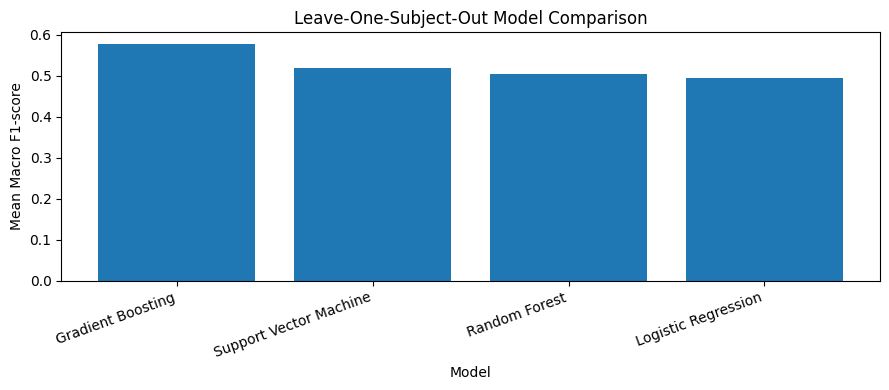

Saved figure to: ..\results\loso_model_comparison_macro_f1.png


In [14]:
# Plot mean macro F1 for each model
plt.figure(figsize=(9, 4))
plt.bar(loso_summary_df["model"], loso_summary_df["mean_macro_f1"])
plt.xlabel("Model")
plt.ylabel("Mean Macro F1-score")
plt.title("Leave-One-Subject-Out Model Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "loso_model_comparison_macro_f1.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

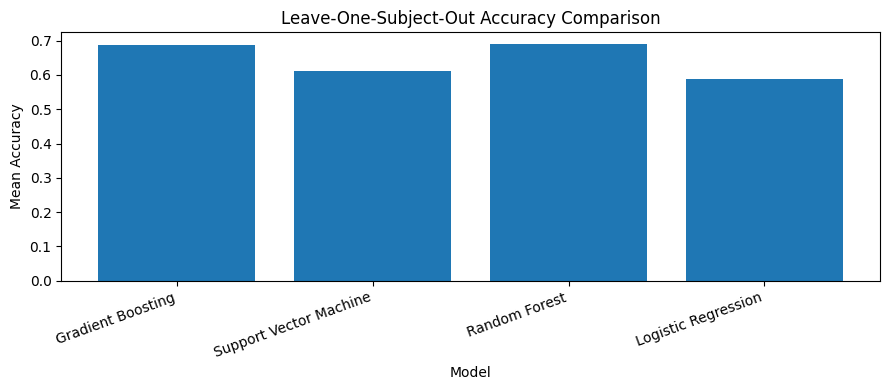

Saved figure to: ..\results\loso_model_comparison_accuracy.png


In [15]:
# Plot mean accuracy for each model
plt.figure(figsize=(9, 4))
plt.bar(loso_summary_df["model"], loso_summary_df["mean_accuracy"])
plt.xlabel("Model")
plt.ylabel("Mean Accuracy")
plt.title("Leave-One-Subject-Out Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "loso_model_comparison_accuracy.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [16]:
# Select best model based on mean macro F1
best_loso_model_name = loso_summary_df.iloc[0]["model"]

print("Best LOSO model:", best_loso_model_name)

Best LOSO model: Gradient Boosting


In [17]:
# Filter fold results for the best model
best_model_subject_results = loso_results_df[
    loso_results_df["model"] == best_loso_model_name
].copy()

# Sort subjects by macro F1
best_model_subject_results = best_model_subject_results.sort_values(
    by="macro_f1",
    ascending=False
)

best_model_subject_results

,model,fold,test_subject,test_samples,accuracy,macro_precision,macro_recall,macro_f1
47,Gradient Boosting,3,S13,145,0.896552,0.928540,0.839105,0.872499
56,Gradient Boosting,12,S6,143,0.874126,0.839192,0.886183,0.853473
46,Gradient Boosting,2,S11,144,0.881944,0.906883,0.784114,0.796209
55,Gradient Boosting,11,S5,144,0.722222,0.681430,0.723291,0.687495
58,Gradient Boosting,14,S8,142,0.661972,0.768254,0.782742,0.675122
50,Gradient Boosting,6,S16,143,0.839161,0.585017,0.666667,0.621169
51,Gradient Boosting,7,S17,149,0.818792,0.566259,0.651027,0.604089
48,Gradient Boosting,4,S14,145,0.793103,0.531532,0.640693,0.568407
57,Gradient Boosting,13,S7,143,0.517483,0.700598,0.685897,0.523172
49,Gradient Boosting,5,S15,145,0.648276,0.574780,0.474671,0.487706


In [18]:
# Save per-subject results for the best model
best_subject_results_path = RESULTS_DIR / "loso_best_model_subject_results.csv"

best_model_subject_results.to_csv(best_subject_results_path, index=False)

print("Saved best model subject results to:", best_subject_results_path)

Saved best model subject results to: ..\results\loso_best_model_subject_results.csv


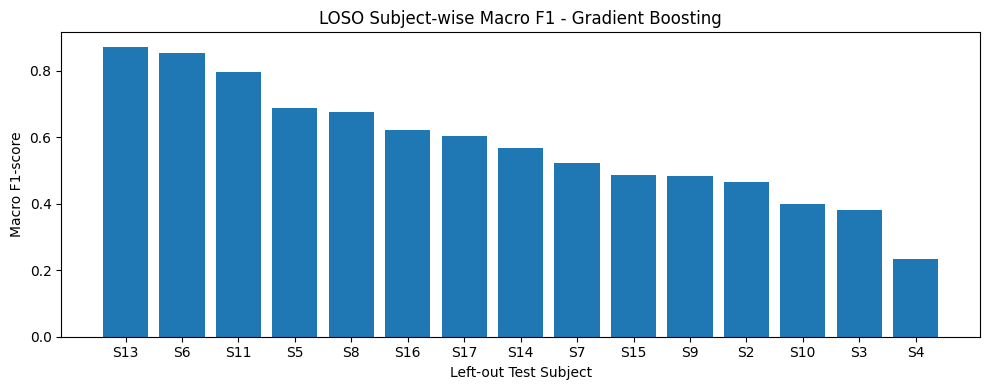

Saved figure to: ..\results\loso_best_model_subject_macro_f1.png


In [19]:
# Plot subject-wise macro F1 for the best LOSO model
plt.figure(figsize=(10, 4))
plt.bar(
    best_model_subject_results["test_subject"],
    best_model_subject_results["macro_f1"]
)
plt.xlabel("Left-out Test Subject")
plt.ylabel("Macro F1-score")
plt.title(f"LOSO Subject-wise Macro F1 - {best_loso_model_name}")
plt.tight_layout()

output_path = RESULTS_DIR / "loso_best_model_subject_macro_f1.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [20]:
# Combine individual fold predictions into one DataFrame
all_predictions_df = pd.concat(all_predictions, ignore_index=True)

print("All predictions shape:", all_predictions_df.shape)

all_predictions_df.head()

All predictions shape: (8604, 4)


,model,test_subject,true_label,predicted_label
0,Logistic Regression,S10,1,3
1,Logistic Regression,S10,1,3
2,Logistic Regression,S10,1,3
3,Logistic Regression,S10,1,2
4,Logistic Regression,S10,1,2


In [21]:
# Save all predictions for analysis
all_predictions_path = RESULTS_DIR / "loso_all_predictions.csv"

all_predictions_df.to_csv(all_predictions_path, index=False)

print("Saved all LOSO predictions to:", all_predictions_path)

Saved all LOSO predictions to: ..\results\loso_all_predictions.csv


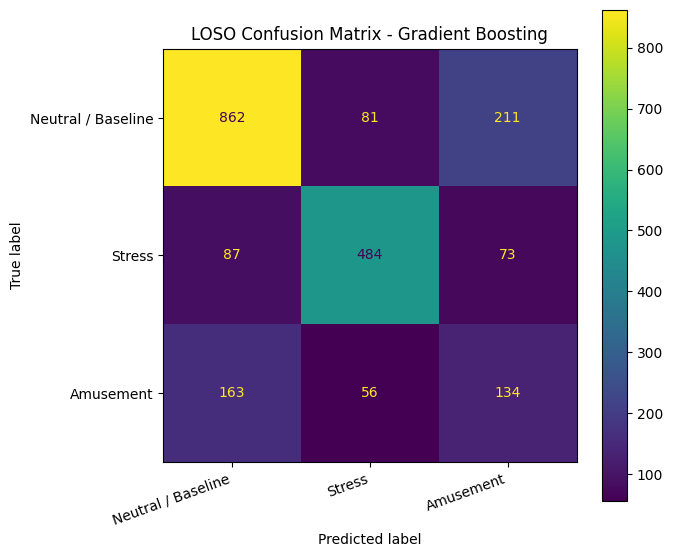

Saved confusion matrix to: ..\results\loso_best_model_confusion_matrix.png


In [22]:
# Filter predictions from the best LOSO model
best_predictions_df = all_predictions_df[
    all_predictions_df["model"] == best_loso_model_name
]

# Create confusion matrix using all LOSO predictions
cm = confusion_matrix(
    best_predictions_df["true_label"],
    best_predictions_df["predicted_label"],
    labels=CLASS_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title(f"LOSO Confusion Matrix - {best_loso_model_name}")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "loso_best_model_confusion_matrix.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved confusion matrix to:", output_path)

In [23]:
# Create global classification report from all LOSO predictions
loso_report = classification_report(
    best_predictions_df["true_label"],
    best_predictions_df["predicted_label"],
    labels=CLASS_LABELS,
    target_names=CLASS_NAMES,
    zero_division=0
)

print(loso_report)

                    precision    recall  f1-score   support

Neutral / Baseline       0.78      0.75      0.76      1154
            Stress       0.78      0.75      0.77       644
         Amusement       0.32      0.38      0.35       353

          accuracy                           0.69      2151
         macro avg       0.63      0.63      0.62      2151
      weighted avg       0.70      0.69      0.69      2151



In [24]:
# Save global LOSO classification report
report_path = RESULTS_DIR / "loso_best_model_classification_report.txt"

with open(report_path, "w") as file:
    file.write(f"Best LOSO model: {best_loso_model_name}\n\n")
    file.write(loso_report)

print("Saved LOSO classification report to:", report_path)

Saved LOSO classification report to: ..\results\loso_best_model_classification_report.txt


In [25]:
# Create a compact summary for README
best_loso_row = loso_summary_df.iloc[0]

loso_final_summary = pd.DataFrame([
    {
        "best_model": best_loso_model_name,
        "mean_accuracy": best_loso_row["mean_accuracy"],
        "std_accuracy": best_loso_row["std_accuracy"],
        "mean_macro_f1": best_loso_row["mean_macro_f1"],
        "std_macro_f1": best_loso_row["std_macro_f1"],
        "number_of_subjects": groups.nunique(),
        "number_of_windows": len(features_df),
        "number_of_features": len(feature_columns)
    }
])

final_summary_path = RESULTS_DIR / "loso_final_summary.csv"

loso_final_summary.to_csv(final_summary_path, index=False)

loso_final_summary

,best_model,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,number_of_subjects,number_of_windows,number_of_features
0,Gradient Boosting,0.687086,0.16375,0.576853,0.180506,15,2151,68
